In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rdkit

# Core libraries
import pandas as pd
import numpy as np
import json
import time
import requests
import os
import glob
from tqdm import tqdm
from math import sqrt
from datetime import datetime
from collections import defaultdict
from math import sqrt

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys, rdFMCS
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from rdkit.ML.Descriptors import MoleculeDescriptors

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.utils import shuffle
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (mean_squared_error, r2_score, roc_auc_score, f1_score)
from sklearn.base import clone
import joblib

# PyTorch (ProtBERT)
import torch
from torch.utils.data import DataLoader

# Transformers (ProtBERT)
from transformers import BertTokenizer, BertModel

# Visual
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display
from tqdm import tqdm

generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = generator.GetFingerprint(mol)
        arr = np.zeros((1,), dtype=int)
        ConvertToNumpyArray(fp, arr)
        return arr
    return None

def fetch_uniprot_sequences(uniprot_ids, delay=0.5):
    base_url = "https://rest.uniprot.org/uniprotkb/"
    headers = {"accept": "application/json"}
    params = {"fields": ["sequence"]}
    id_to_sequence = {}
    for uid in tqdm(uniprot_ids):
        url = base_url + uid
        try:
            response = requests.get(url, headers=headers, params=params)
            if response.ok:
                seq = response.json().get("sequence", {}).get("value", "")
                if seq:
                    id_to_sequence[uid] = seq
            else:
                print(f"[!] Failed for {uid}: {response.status_code}")
        except Exception as e:
            print(f"[!] Error fetching {uid}: {str(e)}")
        time.sleep(delay)
    return id_to_sequence

def batch_embed_sequences(sequences, batch_size=128, max_length=1024, cache_prefix="/content/drive/MyDrive/CompDReAM/protbert/protbert_batch"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
    model = BertModel.from_pretrained("Rostlab/prot_bert").to(device).eval()
    spaced_seqs = [' '.join(list(seq)) for seq in sequences]
    embeddings = []
    for i in tqdm(range(0, len(spaced_seqs), batch_size), desc="Embedding sequences"):
        batch_path = f"{cache_prefix}_{i//batch_size}.npy"
        if os.path.exists(batch_path):
            continue  # already saved
        batch_seqs = spaced_seqs[i:i+batch_size]
        tokens = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        with torch.no_grad():
            outputs = model(**tokens)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        np.save(batch_path, batch_embeddings)
    print("✓ All batches embedded and saved to disk.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 56.8 MB/s eta 0:00:00


In [ ]:
# === STEP 2: Load dataset and generate features ===
use_scoregda = False  # Set to True to use training_dataset_scoregda.csv
use_rdkit_desc = True  # Set to False if you want to skip RDKit descriptors

# === Load dataset ===
dataset_path = "/content/drive/MyDrive/CompDReAM/training_dataset_scoregda.csv" if use_scoregda else "/content/drive/MyDrive/CompDReAM/training_dataset.csv"
df = pd.read_csv(dataset_path, low_memory=False)
df = df.dropna(subset=["Canonical SMILES", "UniProt", "pChEMBL"]).reset_index(drop=True)

# === Morgan fingerprints ===
fps, valid_idx = [], []
for idx, smi in enumerate(df["Canonical SMILES"]):
    arr = smiles_to_morgan_fp(smi)
    if arr is not None:
        fps.append(arr)
        valid_idx.append(idx)

df = df.iloc[valid_idx].reset_index(drop=True)
X_mol = np.array(fps)
print(f"✓ Morgan fingerprints shape: {X_mol.shape}")

# === ProtBERT embeddings ===
df["UniProt_List"] = df["UniProt"].str.split(",").apply(lambda lst: [i.strip() for i in lst])
df["BestUniProt"] = df["UniProt_List"].apply(lambda lst: lst[0])
df["pair"] = df["Canonical SMILES"] + "_" + df["BestUniProt"]

prot_cache_path = "/content/drive/MyDrive/CompDReAM/v3/X_prot.npy"
X_prot = np.memmap(prot_cache_path, dtype='float32', mode='r')
num_samples = len(df)
prot_dim = int(X_prot.shape[0] // num_samples)
X_prot = X_prot[:num_samples * prot_dim].reshape(num_samples, prot_dim)
print(f"✓ ProtBERT embeddings shape: {X_prot.shape}")

# === RDKit descriptors===
if use_rdkit_desc:
    print("Computing RDKit descriptors...")
    desc_names = [desc[0] for desc in Descriptors.descList]
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)
    X_desc = []
    for smi in df["Canonical SMILES"]:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            X_desc.append(calc.CalcDescriptors(mol))
        else:
            X_desc.append([np.nan]*len(desc_names))
    X_desc = np.array(X_desc)
    # Clean and clip any remaining crazy values
    X_desc = np.nan_to_num(X_desc, nan=0.0, posinf=1e6, neginf=-1e6)
    X_desc = np.clip(X_desc, -1e6, 1e6)  # ← NEW: ensure safe float32 range
    print(f"✓ RDKit descriptors shape (cleaned): {X_desc.shape}")
else:
    X_desc = None

# === Target ===
y = df["pChEMBL"].astype(float).values

# === Combine features ===
features = [X_mol, X_prot]
if use_rdkit_desc:
    features.append(X_desc)
X_all = np.concatenate(features, axis=1).astype(np.float32)
np.save("/content/drive/MyDrive/CompDReAM/v5/X_all.npy", X_all)
np.save("/content/drive/MyDrive/CompDReAM/v5/y.npy", y)
print("✓ Saved X_all and y to v5 folder")
print(f"✓ Final feature matrix shape: {X_all.shape}")

[16:35:37] WARNING: not removing hydrogen atom without neighbors


✓ Morgan fingerprints shape: (116752, 2048)
✓ ProtBERT embeddings shape: (116752, 1024)
Computing RDKit descriptors...


[16:54:16] WARNING: not removing hydrogen atom without neighbors
[16:54:16] WARNING: not removing hydrogen atom without neighbors


✓ RDKit descriptors shape (cleaned): (116752, 217)
✓ Saved X_all and y to v5 folder
✓ Final feature matrix shape: (116752, 3289)


In [ ]:
from sklearn.utils import shuffle
from collections import defaultdict

# === STEP 3: Split and train ===
# === Stratified split with no pair leakage ===
df["bin"] = pd.qcut(df["pChEMBL"], q=5, labels=False, duplicates="drop")
unique_pairs = df.drop_duplicates(subset="pair")

# Stratify on binned pChEMBL (approximate by first occurrence of each pair)
pair_bins = unique_pairs.set_index("pair")["bin"].to_dict()
df["pair_bin"] = df["pair"].map(pair_bins)

train_pairs, test_pairs = train_test_split(
    list(pair_bins.keys()), test_size=0.2, stratify=list(pair_bins.values()), random_state=42
)

train_idx = df[df["pair"].isin(train_pairs)].index
test_idx = df[df["pair"].isin(test_pairs)].index

# === Final splits ===
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# === Models to evaluate ===
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    "SVR (RBF)": SVR(kernel="rbf", C=1.0)
}

results = defaultdict(dict)
save_dir = "/content/drive/MyDrive/CompDReAM/v5"
os.makedirs(save_dir, exist_ok=True)

for name, model in models.items():
    print(f"\n🔍 Training {name}...")
    model.fit(X_train, y_train)

    # Save model
    model_path = os.path.join(save_dir, f"{name.replace(' ', '_').replace('(', '').replace(')', '')}.pkl")
    joblib.dump(model, model_path)
    print(f"✓ Saved model to {model_path}")

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))

    results[name]["R2"] = r2
    results[name]["RMSE"] = rmse

    print(f"→ R²: {r2:.3f}, RMSE: {rmse:.3f}")

Train size: (93527, 3289), Test size: (23225, 3289)

🔍 Training Random Forest...
✓ Saved model to /content/drive/MyDrive/CompDReAM/v5/Random_Forest.pkl
→ R²: 0.726, RMSE: 0.522

🔍 Training Gradient Boosting...
✓ Saved model to /content/drive/MyDrive/CompDReAM/v5/Gradient_Boosting.pkl
→ R²: 0.601, RMSE: 0.629

🔍 Training XGBoost...
✓ Saved model to /content/drive/MyDrive/CompDReAM/v5/XGBoost.pkl
→ R²: 0.705, RMSE: 0.541

🔍 Training LightGBM...
✓ Saved model to /content/drive/MyDrive/CompDReAM/v5/LightGBM.pkl
→ R²: 0.691, RMSE: 0.554

🔍 Training SVR (RBF)...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✓ Saved model to /content/drive/MyDrive/CompDReAM/v5/SVR_RBF.pkl
→ R²: -0.124, RMSE: 1.056


In [ ]:
df["bin"] = pd.qcut(df["pChEMBL"], q=5, labels=False, duplicates="drop")
unique_pairs = df.drop_duplicates(subset="pair")

pair_bins = unique_pairs.set_index("pair")["bin"].to_dict()
df["pair_bin"] = df["pair"].map(pair_bins)

train_pairs, test_pairs = train_test_split(
    list(pair_bins.keys()), test_size=0.2, stratify=list(pair_bins.values()), random_state=42
)

train_idx = df[df["pair"].isin(train_pairs)].index
test_idx = df[df["pair"].isin(test_pairs)].index

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

model_dir = "/content/drive/MyDrive/CompDReAM/v5"
all_files = os.listdir(model_dir)

model_files = [f for f in all_files if f.endswith(".pkl") and "SVR" not in f]

results = []
for model_file in model_files:
    model_name = model_file.replace(".pkl", "").replace("_", " ")
    model_path = os.path.join(model_dir, model_file)
    model = joblib.load(model_path)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))

    results.append({"Model": model_name, "R2": r2, "RMSE": rmse})

results_df = pd.DataFrame(results)
print(results_df)

Train size: (93527, 3289), Test size: (23225, 3289)
               Model        R2      RMSE
0      Random Forest  0.726061  0.521539
1  Gradient Boosting  0.601336  0.629164
2            XGBoost  0.705500  0.540758
3           LightGBM  0.691024  0.553889


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/tmp/ipython-input-26-1874754528.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(bin_labels_with_counts)
/tmp/ipython-input-26-1874754528.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metric_names, x=values, ax=ax2, palette=colors)
/tmp/ipython-input-26-1874754528.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(bin_labels_with_counts)
/tmp/ipython-input-26-1874754528.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metric_names, x=values, ax=ax2, palette=colors

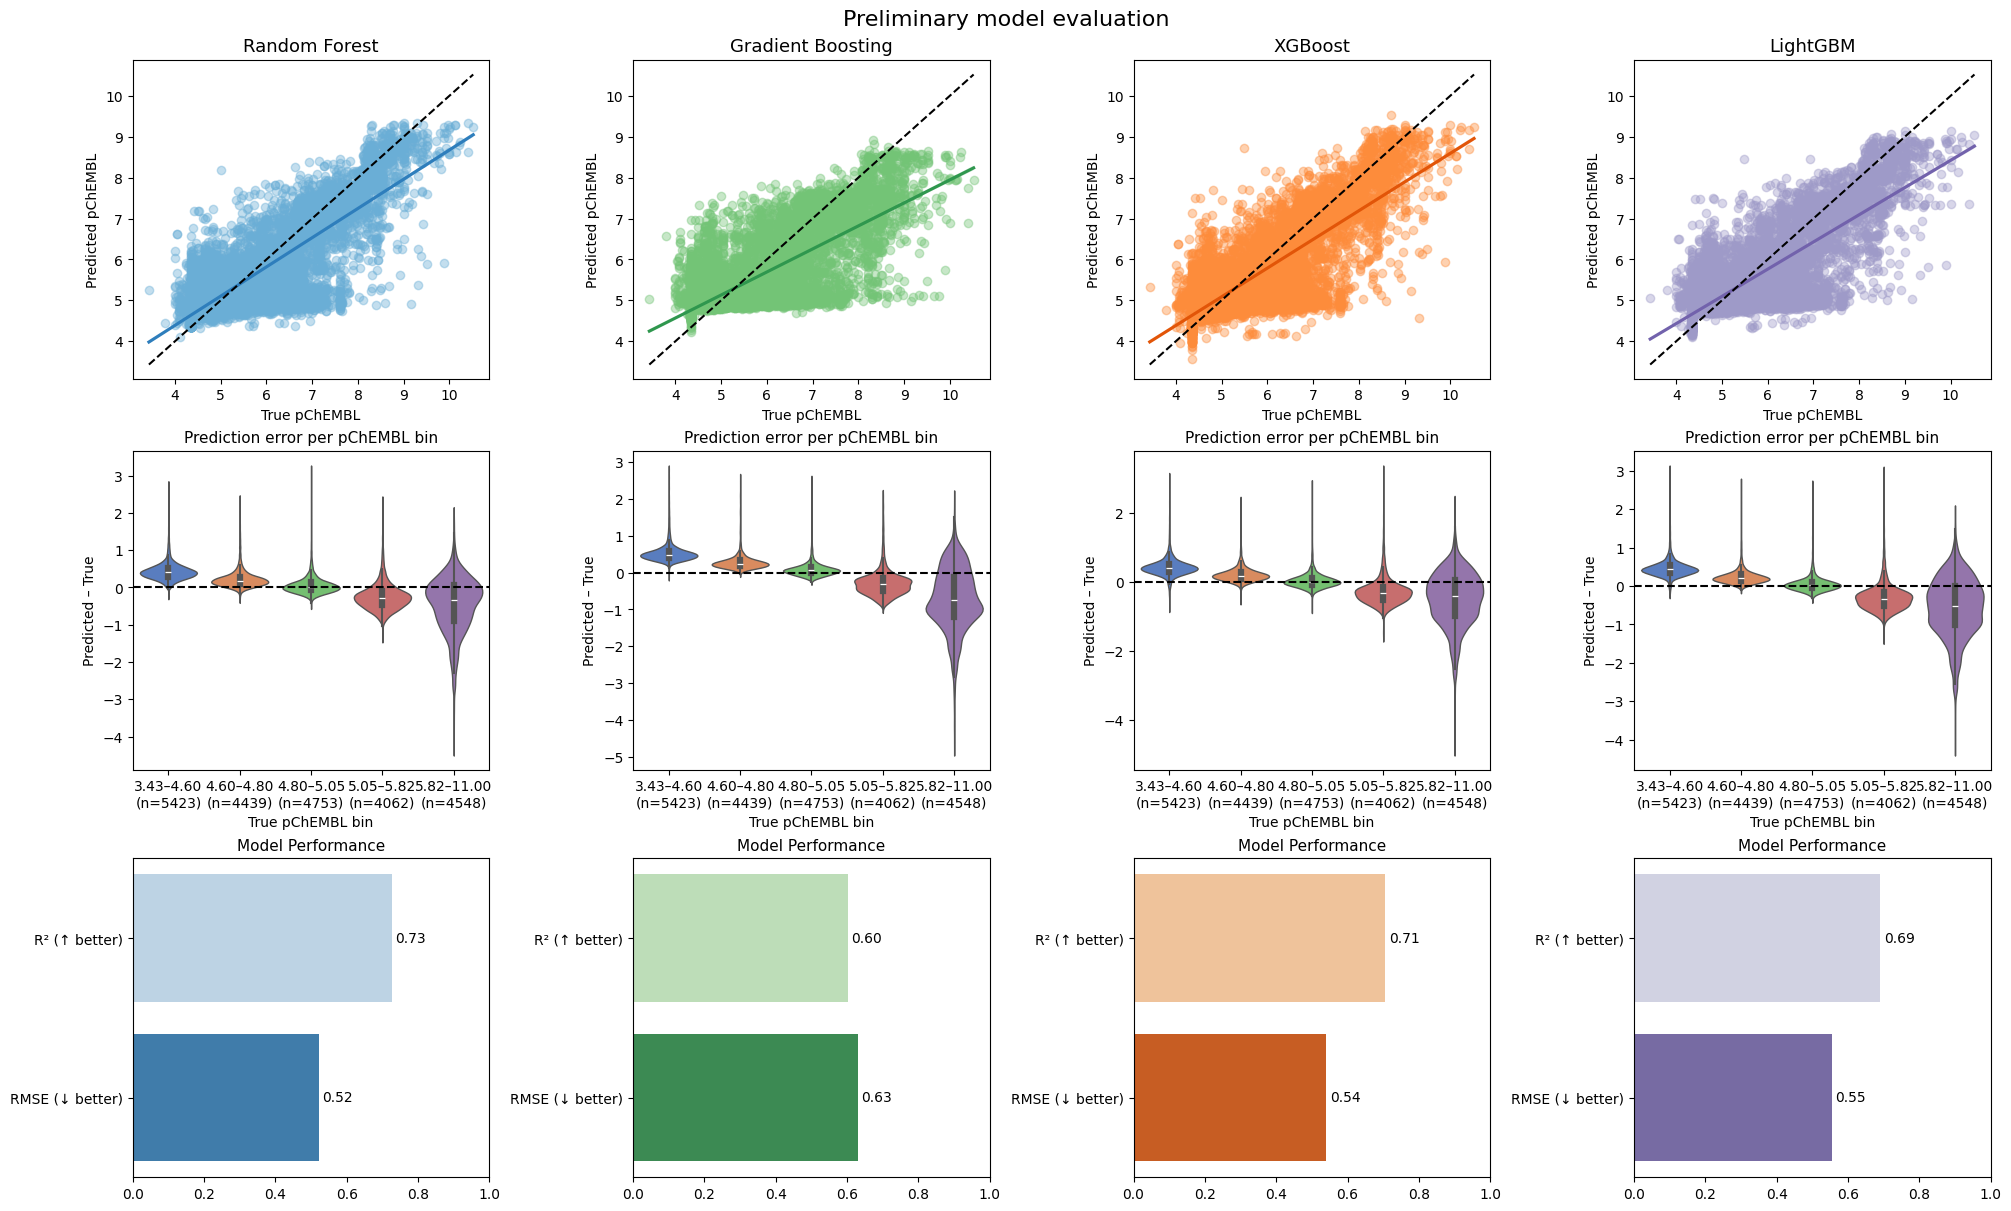

In [ ]:
from matplotlib.ticker import MaxNLocator

_, bin_edges = pd.qcut(df["pChEMBL"], q=5, retbins=True, duplicates="drop")
bin_labels = [f"{bin_edges[i]:.2f}–{bin_edges[i+1]:.2f}" for i in range(len(bin_edges)-1)]
y_bins = pd.cut(y_test, bins=bin_edges, labels=bin_labels, include_lowest=True)

n_models = len(results_df)
fig, axes = plt.subplots(3, n_models, figsize=(5 * n_models, 12), constrained_layout=True)

for i, model_name in enumerate(results_df["Model"]):
    model_path = os.path.join(model_dir, f"{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.pkl")
    model = joblib.load(model_path)
    y_pred = model.predict(X_test)
    errors = y_pred - y_test

    ax0 = axes[0, i]
    ax0.scatter(y_test, y_pred, alpha=0.4, color=model_palette[model_name][1])
    sns.regplot(x=y_test, y=y_pred, scatter=False, ax=ax0, color=model_palette[model_name][2])
    ax0.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--", color="black")
    ax0.set_title(model_name, fontsize=13)
    ax0.set_xlabel("True pChEMBL")
    ax0.set_ylabel("Predicted pChEMBL")
    ax1 = axes[1, i]
    error_df = pd.DataFrame({
        "Bin": y_bins,
        "Prediction error": errors
    })

    sns.violinplot(data=error_df, x="Bin", y="Prediction error", hue="Bin", ax=ax1, palette="muted", linewidth=1, legend=False)
    bin_counts = pd.Series(y_bins).value_counts(sort=False)
    bin_labels_with_counts = [f"{label}\n(n={bin_counts[label]})" for label in y_bins.categories]
    ax1.set_xticklabels(bin_labels_with_counts)
    ax1.axhline(0, linestyle="--", color="black")
    ax1.set_title("Prediction error per pChEMBL bin", fontsize=11)
    ax1.set_xlabel("True pChEMBL bin")
    ax1.set_ylabel("Predicted – True")

    ax2 = axes[2, i]
    r2 = results_df.loc[results_df["Model"] == model_name, "R2"].values[0]
    rmse = results_df.loc[results_df["Model"] == model_name, "RMSE"].values[0]
    metric_names = ["R² (↑ better)", "RMSE (↓ better)"]
    values = [r2, rmse]
    colors = [model_palette[model_name][0], model_palette[model_name][2]]
    sns.barplot(y=metric_names, x=values, ax=ax2, palette=colors)
    ax2.set_xlim(0, max(1.0, max(values)*1.2))
    ax2.set_title("Model Performance", fontsize=11)
    for j, val in enumerate(values):
        ax2.text(val + 0.01, j, f"{val:.2f}", va="center", ha="left", fontsize=10)

# === Title ===
plt.suptitle("Preliminary model evaluation", fontsize=16)
plt.show()

In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt
import joblib
import os

# === Select training and test sets ===
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# === Define pipeline with scaling and SVR ===
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

# === Hyperparameter grid ===
param_grid = {
    "svr__C": [0.1, 1, 10],
    "svr__gamma": ["scale", 0.01, 0.001]
}

# === Grid search with 3-fold CV ===
grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("\n🔍 Tuning SVR with grid search...")
grid.fit(X_train, y_train)

# === Evaluate best model ===
best_svr = grid.best_estimator_
y_pred = best_svr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))
print(f"✓ Best SVR parameters: {grid.best_params_}")
print(f"→ Final R²: {r2:.3f}, RMSE: {rmse:.3f}")

# === Save best model ===
svr_path = "/content/drive/MyDrive/CompDReAM/v5/SVR_TUNED.pkl"
joblib.dump(best_svr, svr_path)
print(f"✓ Saved best SVR model to {svr_path}")


🔍 Tuning SVR with grid search...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
